# Tuning hyperparameters

Load data:

In [1]:
import os
import sys

notebook_dir = os.getcwd()
shallow_dir = os.path.dirname(notebook_dir)
python_dir = os.path.dirname(shallow_dir)
modules_path = os.path.join(python_dir, 'Modules')

sys.path.append(modules_path)

In [2]:
from read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\Christine\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\Christine\Documents\Python\Speciale_Kode
Data_folder: c:\Users\Christine\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78900, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78900, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Import model and choose parameter search grid

In [3]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf', 'linear', 'poly']
}
num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


Total number of combinations to test: 144


## Choose validation setup


**Setup 1**

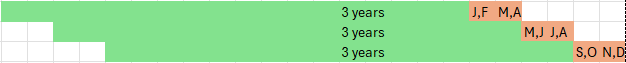

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [4]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [5]:
from Cross_Validation_runner import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 17 * 168,     # 168 hours = 1 week
        stride = 17 * 168,              
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
    )
    row = {**params, "avg_smape": combination_results["overall_avg_weekly_smape"]}
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(python_dir, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = "DK1_hyperparameter_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_hyperparameter_results_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


c:\Users\Christine\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total number of combinations to test: 144

Combination 1/144: {'C': 0.1, 'gamma': 'scale', 'epsilon': 0.01, 'kernel': 'rbf'}
Number of folds: 1
Fold 1: Train from 2021-09-05 00:00:00 to 2024-09-03 23:00:00,
        Validation from 2024-09-04 00:00:00 to 2024-12-31 23:00:00


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(



Average RMSE across all weeks in all folds: 434.325

Average MAE across all weeks in all folds: 321.704

Average SMAPE across all weeks in all folds: 56.818

Combination 2/144: {'C': 0.1, 'gamma': 'scale', 'epsilon': 0.01, 'kernel': 'linear'}
Number of folds: 1
Fold 1: Train from 2021-09-05 00:00:00 to 2024-09-03 23:00:00,
        Validation from 2024-09-04 00:00:00 to 2024-12-31 23:00:00


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


...


Average RMSE across all weeks in all folds: 476.562

Average MAE across all weeks in all folds: 361.779

Average SMAPE across all weeks in all folds: 59.762

Combination 101/144: {'C': 10, 'gamma': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
Number of folds: 1
Fold 1: Train from 2021-09-05 00:00:00 to 2024-09-03 23:00:00,
        Validation from 2024-09-04 00:00:00 to 2024-12-31 23:00:00


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(



Average RMSE across all weeks in all folds: 449.787

Average MAE across all weeks in all folds: 337.692

Average SMAPE across all weeks in all folds: 64.802

Combination 102/144: {'C': 10, 'gamma': 0.1, 'epsilon': 0.01, 'kernel': 'poly'}
Number of folds: 1
Fold 1: Train from 2021-09-05 00:00:00 to 2024-09-03 23:00:00,
        Validation from 2024-09-04 00:00:00 to 2024-12-31 23:00:00


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:258: UserWarning: NaN detected at block 5, step 72 (time=2024-10-05 00:00:00) in features: ['Price_lag1']
  warnings.warn(
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:258: UserWarning: NaN detected at block 5, step 95 (time=2024-10-05 23:00:00) in features: ['Price_lag1', 'Price_lag24']
  warnings.warn(
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:258: UserWarning: NaN detected at block 5, step 118 (time=2024-10-06 22:00:00) in features: ['Price_lag1', 'Price_lag24']
  warnings.warn(
c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:258: UserWarning: NaN detected at block 5

ValueError: Input contains NaN.

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [ ]:
from Cross_Validation_runner import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 17 * 168,     # 168 hours = 1 week
        stride = 17 * 168,              
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
    )
    row = {**params, "avg_smape": combination_results["overall_avg_weekly_smape"]}
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(python_dir, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = "DK2_hyperparameter_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_hyperparameter_results_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False)

results_df.to_csv(filename, index=False, decimal=",")
# print(results_df.to_string(index=False))
